In [1]:
import numpy as np

In [2]:
with np.load("definitely_mnist.npz") as f:
    x_train, y_train = f["x_train"], f["y_train"]
    x_test, y_test = f["x_test"], f["y_test"]

Check how labels are positioned

In [3]:
for class_label in range(10):
    idx = np.where(y_train == class_label)[0]
    print(f"Class {class_label}: {idx}")

Class 0: [   0    1    2 ... 5920 5921 5922]
Class 1: [ 5923  5924  5925 ... 12662 12663 12664]
Class 2: [12665 12666 12667 ... 18620 18621 18622]
Class 3: [18623 18624 18625 ... 24751 24752 24753]
Class 4: [24754 24755 24756 ... 30593 30594 30595]
Class 5: [30596 30597 30598 ... 36014 36015 36016]
Class 6: [36017 36018 36019 ... 41932 41933 41934]
Class 7: [41935 41936 41937 ... 48197 48198 48199]
Class 8: [48200 48201 48202 ... 54048 54049 54050]
Class 9: [54051 54052 54053 ... 59997 59998 59999]


They are located sequentially, so train shuffle is a must

Now let's see test labels

In [4]:
np.unique(y_test)

array([9], dtype=uint8)

Calculated standard deviation across BATCH dimension

In [5]:
np.allclose(np.std(x_test, axis=0), 0.0, atol=1e-9)

True

Compare every sample with the 0-th row of test set

In [6]:
np.abs(x_test - x_test[0]).max()

np.float64(0.0)

We can conclude that test contains the only one repeated image, so we can't actually use this split for evaluation

In [7]:
import matplotlib.pyplot as plt

Let's look at the training images

In [8]:
def visualize(imgs: np.ndarray, figscale: int = 3) -> None:
    _, axes = plt.subplots(1, len(imgs), figsize=(figscale * len(imgs), figscale))
    for img, ax in zip(imgs, np.atleast_1d(axes), strict=True):
        ax.imshow(img, cmap="gray")
        ax.axis("off")

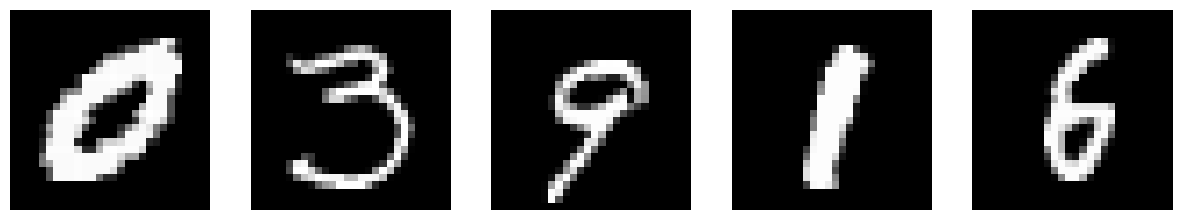

In [9]:
idx = np.arange(x_train.shape[0])
np.random.seed(0)
np.random.shuffle(idx)
visualize(x_train[idx[:5]])

And test images

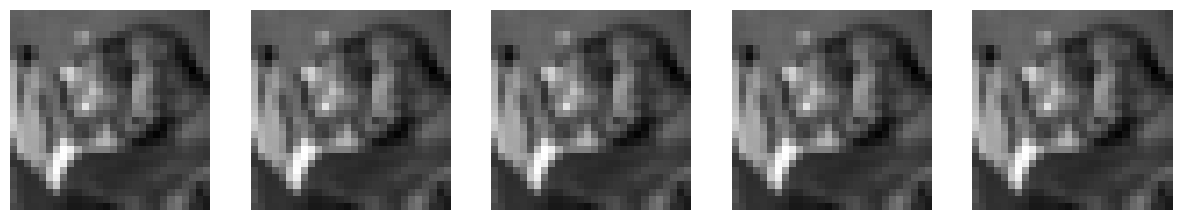

In [10]:
visualize(x_test[:5])